In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
raw_csv_path = 'HTRU_2.csv'

In [13]:
#Importing and reading file
raw_df = pd.read_csv(raw_csv_path, header=None)

In [15]:
#Giving name to columns
raw_df.columns = ['Profile_mean', 'Profile_stdev', 'Profile_skewness', 'Profile_kurtosis',
              'DM_mean', 'DM_stdev', 'DM_skewness', 'DM_kurtosis', 'Class']

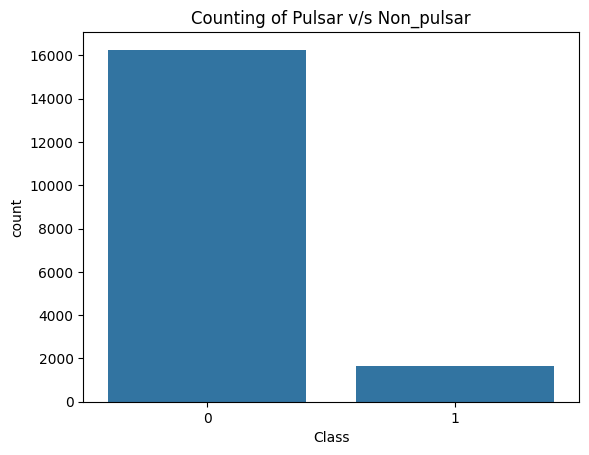

In [41]:
sns.countplot(data=raw_df, x='Class');
plt.title('Counting of Pulsar v/s Non_pulsar');
#0 as non_pulsar and 1 as pulsar

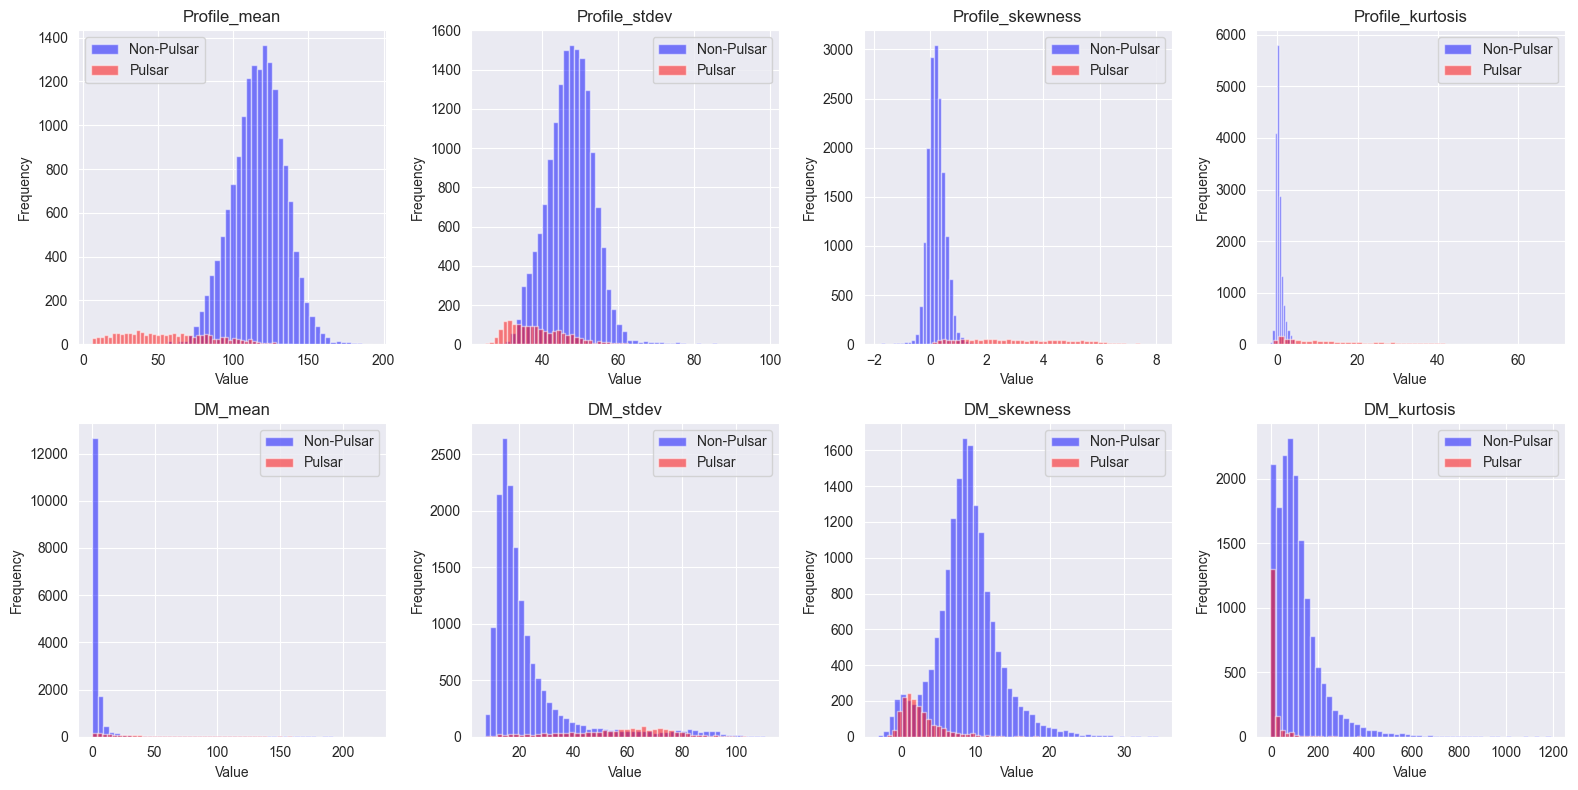

In [44]:
sns.set_style("darkgrid")

# Create a figure with 2 rows and 4 columns (8 features total)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Flatten axes for easy looping
axes = axes.flatten()

# List of feature columns (all except Class)
features = ['Profile_mean', 'Profile_stdev', 'Profile_skewness', 'Profile_kurtosis',
            'DM_mean', 'DM_stdev', 'DM_skewness', 'DM_kurtosis']

# Loop through each feature and create a histogram
for i, feature in enumerate(features):
    # Plot histogram for Class 0 (non-pulsars)
    axes[i].hist(raw_df[raw_df['Class'] == 0][feature], bins=50, alpha=0.5, label='Non-Pulsar', color='blue')
    # Plot histogram for Class 1 (pulsars)
    axes[i].hist(raw_df[raw_df['Class'] == 1][feature], bins=50, alpha=0.5, label='Pulsar', color='red')
    axes[i].set_title(feature)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

# Adjust layout so plots don't overlap
plt.tight_layout()
plt.show()

In [45]:
#Training part

In [46]:
from sklearn.model_selection import train_test_split

In [52]:
input_tags = raw_df[raw_df.columns[0:-1]]
output_tags = raw_df.Class

In [54]:
X_train, X_test, y_train, y_test = train_test_split(input_tags, output_tags, test_size=0.2, random_state=42)

In [55]:
raw_df.describe()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,Class
count,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000,17898.000000
mean,111.079968,46.549532,0.477857,1.770279,12.614400,26.326515,8.303556,104.857709,0.091574
std,25.652935,6.843189,1.064040,6.167913,29.472897,19.470572,4.506092,106.514540,0.288432
min,5.812500,24.772042,-1.876011,-1.791886,0.213211,7.370432,-3.139270,-1.976976,0.000000
25%,100.929688,42.376018,0.027098,-0.188572,1.923077,14.437332,5.781506,34.960504,0.000000
50%,115.078125,46.947479,0.223240,0.198710,2.801839,18.461316,8.433515,83.064556,0.000000
75%,127.085938,51.023202,0.473325,0.927783,5.464256,28.428104,10.702959,139.309330,0.000000
max,192.617188,98.778911,8.069522,68.101622,223.392141,110.642211,34.539844,1191.000837,1.000000


In [56]:
# Check 99th percentile vs max
print(raw_df[features].describe(percentiles=[0.01, 0.99]))

       Profile_mean  Profile_stdev  Profile_skewness  Profile_kurtosis  \
count  17898.000000   17898.000000      17898.000000      17898.000000   
mean     111.079968      46.549532          0.477857          1.770279   
std       25.652935       6.843189          1.064040          6.167913   
min        5.812500      24.772042         -1.876011         -1.791886   
1%        19.233672      30.057644         -0.479133         -0.833862   
99%      155.742891      61.975944          5.701819         35.463057   
max      192.617188      98.778911          8.069522         68.101622   

            DM_mean      DM_stdev   DM_skewness   DM_kurtosis  
count  17898.000000  17898.000000  17898.000000  17898.000000  
mean      12.614400     26.326515      8.303556    104.857709  
std       29.472897     19.470572      4.506092    106.514540  
min        0.213211      7.370432     -3.139270     -1.976976  
1%         0.603654      9.307935     -0.875384     -1.713688  
99%      155.817759    

In [57]:
from sklearn.preprocessing import RobustScaler

# Initialize and apply the scaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
X_train_scaled

array([[-0.24438495,  0.06731423, -0.07196336, ..., -0.03122283,
         0.00717495,  0.00992397],
       [ 0.24260003,  0.45985835, -0.314438  , ..., -0.49467445,
         1.1668782 ,  1.52561421],
       [-0.56804998, -0.36259842,  0.02172744, ..., -0.33697246,
         1.16043202,  1.26337605],
       ...,
       [ 0.03227726, -0.43153383,  0.98630118, ..., -0.49195125,
         1.75061545,  2.18769663],
       [ 0.77986018,  0.34685103, -0.70226714, ...,  0.22088814,
        -0.21004307, -0.19826984],
       [ 0.21106649,  0.40922778,  0.2751945 , ..., -0.48007801,
         1.87385833,  2.3533084 ]], shape=(14318, 8))

In [59]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the model — ADD class_weight='balanced'
model = LogisticRegression(class_weight='balanced', random_state=42)

# 2. Train the model
model.fit(X_train_scaled, y_train)

# 3. Make predictions
predictions = model.predict(X_test_scaled)

# 4. Get probabilities
probs = model.predict_proba(X_test_scaled)

In [63]:
predictions

array([0, 1, 0, ..., 0, 1, 1], shape=(3580,))

In [64]:
probs

array([[9.55315836e-01, 4.46841643e-02],
       [3.51312905e-02, 9.64868709e-01],
       [8.67740216e-01, 1.32259784e-01],
       ...,
       [9.56345732e-01, 4.36542680e-02],
       [4.15689884e-01, 5.84310116e-01],
       [2.97716186e-04, 9.99702284e-01]], shape=(3580, 2))

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3259
           1       0.77      0.92      0.84       321

    accuracy                           0.97      3580
   macro avg       0.88      0.94      0.91      3580
weighted avg       0.97      0.97      0.97      3580


Confusion Matrix:
[[3173   86]
 [  27  294]]

ROC-AUC Score: 0.9743743422241212


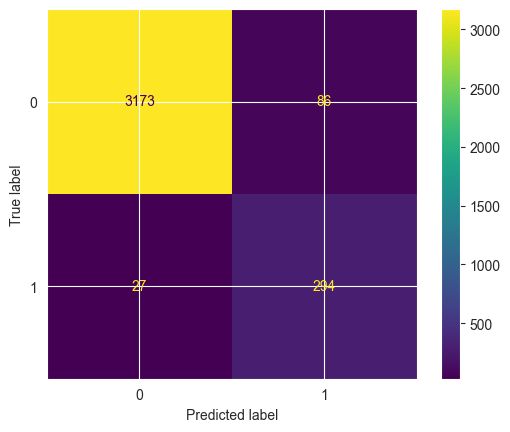

In [66]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

# Classification report
print("Classification Report:")
print(classification_report(y_test, predictions))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

# ROC-AUC score
print("\nROC-AUC Score:", roc_auc_score(y_test, probs[:, 1]))

# Optional: Visual confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, predictions);

In [67]:
import joblib

# Save the trained model
joblib.dump(model, 'pulsar_classifier.pkl')

# Save the scaler
joblib.dump(scaler, 'robust_scaler.pkl')

['robust_scaler.pkl']